In [36]:
# Imports 
# ==========

import collections
import re
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt

**Raw to Sequenced Data**

- Load text as strings into memory.
- Split strings into tokens.
- Build a vocab dictionary to associate each vocab token with a numerical index.
- Convert the text into sequence of numerical indices. (Encoding)

In [37]:
# Data Downloader and Processor
# ==============================

class TxtDataProcessor:
    def __init__(self, url: str, file_name: str):
        data_dir = Path("data")
        data_dir.mkdir(parents=True, exist_ok=True)
        file_path = data_dir / file_name

        if not file_path.exists():
            urlretrieve(url, file_path)
        self.file_path = file_path

    def _read_file(self):
        with open(self.file_path) as f:
            self.data = f.read()

    def _preprocess(self):
        self.preprocessed_data = re.sub('^A-Za-z]+', ' ', self.data).lower()

    def _tokenize(self) -> list[str]:
        return list(self.preprocessed_data)

URL = "https://www.gutenberg.org/files/35/35-0.txt"
FILE_NAME = "time_machine.txt"

In [38]:
# Data Debug
# ============

data = TxtDataProcessor(URL, FILE_NAME)
data._read_file()
if data.data is not None:
    print(data.data[:60])

data._preprocess()
if data.preprocessed_data is not None:
    print(data.preprocessed_data[:60])
    
tokens = data._tokenize()
','.join(tokens[:30])

*** START OF THE PROJECT GUTENBERG EBOOK 35 ***




The Time
*** start of the project gutenberg ebook 35 ***




the time


'*,*,*, ,s,t,a,r,t, ,o,f, ,t,h,e, ,p,r,o,j,e,c,t, ,g,u,t,e,n'

In [39]:
class Vocab:
    def __init__(self, tokens: list[str] = [], min_freq: int = 0, reserved_tokens:list[str] = []):
        # flatten the token list (if needed)
        if tokens and isinstance(tokens[0], list):
            tokens = []
            for line in tokens:
                for token in line:
                    tokens.append(token)
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(
            counter.items(),
            key = lambda x: x[1], # sort by frequency
            reverse = True
        )
        self.index_to_token = sorted(set(
                ['<unk>'] + 
                reserved_tokens + 
                [
                    token for token, freq in self.token_freqs if freq >= min_freq
                ]
            ))
        self.token_to_index = {
            token: idx for idx, token in enumerate(self.index_to_token)
        }
    
    def __len__(self):
        return len(self.index_to_token)

    def __getitem__(self, tokens: list | tuple):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_index.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices: list[int]):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.index_to_token[int(index)] for index in indices]
        return self.index_to_token[indices]

    @property
    def unk(self):
        return self.token_to_index['<unk>']

In [40]:
vocab = Vocab(tokens)
indices = vocab[tokens[:10]]
print('indices:', indices)
print('words:', vocab.to_tokens(indices))

indices: [5, 5, 5, 1, 36, 37, 18, 35, 37, 1]
words: ['*', '*', '*', ' ', 's', 't', 'a', 'r', 't', ' ']


In [41]:
corpus = [vocab[token] for token in tokens]
len(corpus), len(vocab)

(179799, 54)

In [42]:
# Language Stats
# ===================
text = data.preprocessed_data
words = text.split()
vocab = Vocab(words)
freqs = [freq for token, freq in vocab.token_freqs]
vocab.token_freqs[:10]

[('the', 2255),
 ('and', 1199),
 ('i', 1175),
 ('of', 1156),
 ('a', 803),
 ('to', 671),
 ('in', 540),
 ('was', 535),
 ('my', 436),
 ('that', 404)]

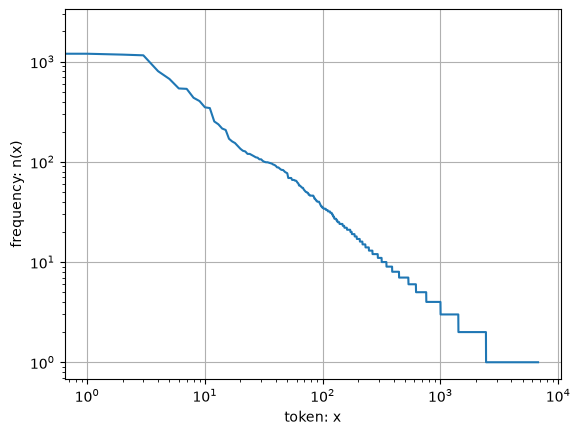

In [45]:
plt.plot(freqs)
plt.xlabel("token: x")
plt.ylabel("frequency: n(x)")
plt.xscale('log')
plt.yscale('log')
plt.grid()

In [46]:
# Bigram token analysis
# =======================

bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[('of--the', 311),
 ('in--the', 171),
 ('i--had', 127),
 ('and--the', 109),
 ('i--was', 108),
 ('the--time', 96),
 ('it--was', 87),
 ('to--the', 85),
 ('of--a', 71),
 ('as--i', 70)]

In [47]:
# Trigram token analysis
# =======================

trigram_tokens = ['--'.join(triple) for triple in zip(
    words[:-2], words[1:-1], words[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[('the--time--traveller', 33),
 ('it--seemed--to', 15),
 ('i--did--not', 14),
 ('it--was--a', 13),
 ('the--time--machine', 12),
 ('said--the--time', 12),
 ('i--saw--the', 12),
 ('i--began--to', 12),
 ('a--kind--of', 11),
 ('said--the--medical', 11)]

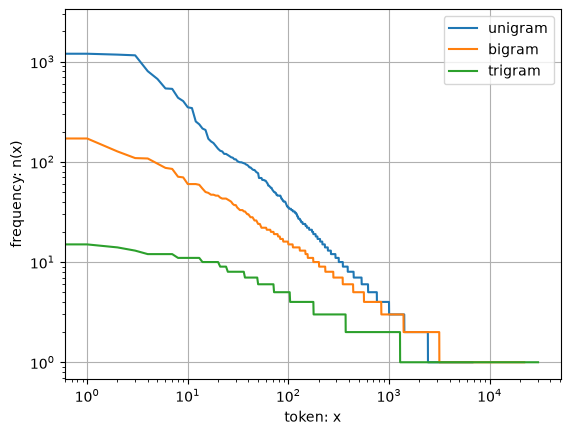

In [ ]:
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]
plt.plot(freqs, label="unigram")
plt.plot(bigram_freqs, label="bigram")
plt.plot(trigram_freqs, label="trigram")
plt.xlabel("token: x")
plt.ylabel("frequency: n(x)")
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()